In [2]:
import os
from dotenv import load_dotenv
from huggingface_hub import login
from pricer.items_7 import Item
from tqdm.notebook import tqdm
from transformers import AutoTokenizer
import matplotlib.pyplot as plt


## Upload final dataset

In [28]:
LITE_MODE = True

load_dotenv(override=True)
hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [29]:
username = "SujithVarma2005"
dataset = f"{username}/items_lite" if LITE_MODE else f"{username}/items_full"

train, val, test = Item.from_hub(dataset)
items = train + val + test

print(f"Loaded {len(train):,} training items, {len(val):,} validation items, {len(test):,} test items")

Loaded 40 training items, 5 validation items, 5 test items


In [4]:
BASE_MODEL = "meta-llama/Llama-3.2-3B"
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

In [30]:
token_counts = [item.count_tokens(tokenizer) for item in tqdm(items)]

  0%|          | 0/50 [00:00<?, ?it/s]

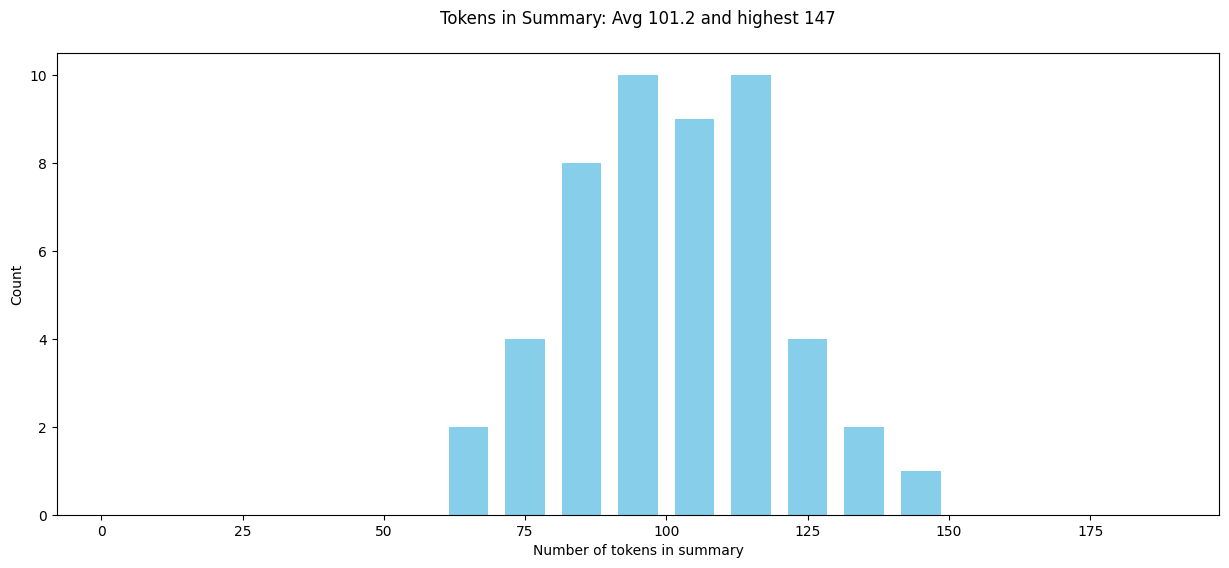

In [31]:
plt.figure(figsize=(15, 6))
plt.title(f"Tokens in Summary: Avg {sum(token_counts)/len(token_counts):,.1f} and highest {max(token_counts):,}\n")
plt.xlabel('Number of tokens in summary')
plt.ylabel('Count')
plt.hist(token_counts, rwidth=0.7, color="skyblue", bins=range(0, 200, 10))
plt.show()

In [32]:
CUTOFF = 110
cut = len([count for count in token_counts if count > CUTOFF])
print(f"With this CUTOFF, we will truncate {cut:,} items which is {cut/len(items):.1%}")


With this CUTOFF, we will truncate 16 items which is 32.0%


In [34]:
print(train[33].summary)

Title: Nest Cam IQ Indoor Mini  
Category: Security Cameras  
Brand: NEST LABS INC.  
Description: Smart indoor camera that delivers crisp HD video, detects people, and sends intelligent alerts.  
Details: Features a 4K sensor with 12‑x digital zoom, HDR imaging, 130° wide‑angle view, two‑way audio, and built‑in Google Assistant for 24/7 live streaming and advanced motion tracking.


In [35]:
for item in tqdm(train+val):
    item.make_prompts(tokenizer, CUTOFF, True)
for item in tqdm(test):
    item.make_prompts(tokenizer, CUTOFF, False)

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

In [40]:
print("PROMPT:")
print(test[0].prompt)
print("COMPLETION:")
print(test[0].completion)


PROMPT:
What does this cost to the nearest dollar?

Title: Ohlins YA 335 Road & Street Shock Absorber  
Category: Motorcycle Suspension  
Brand: Ohlins  
Description: A lightweight, high‑performance shock designed for both street and racing use.  
Details: Features a precision‑drawn steel shock body paired with an aluminum reservoir for superior strength and reduced weight.

Price is $
COMPLETION:
698.99


In [41]:
prompt_token_counts = [item.count_prompt_tokens(tokenizer) for item in tqdm(items)]

  0%|          | 0/50 [00:00<?, ?it/s]

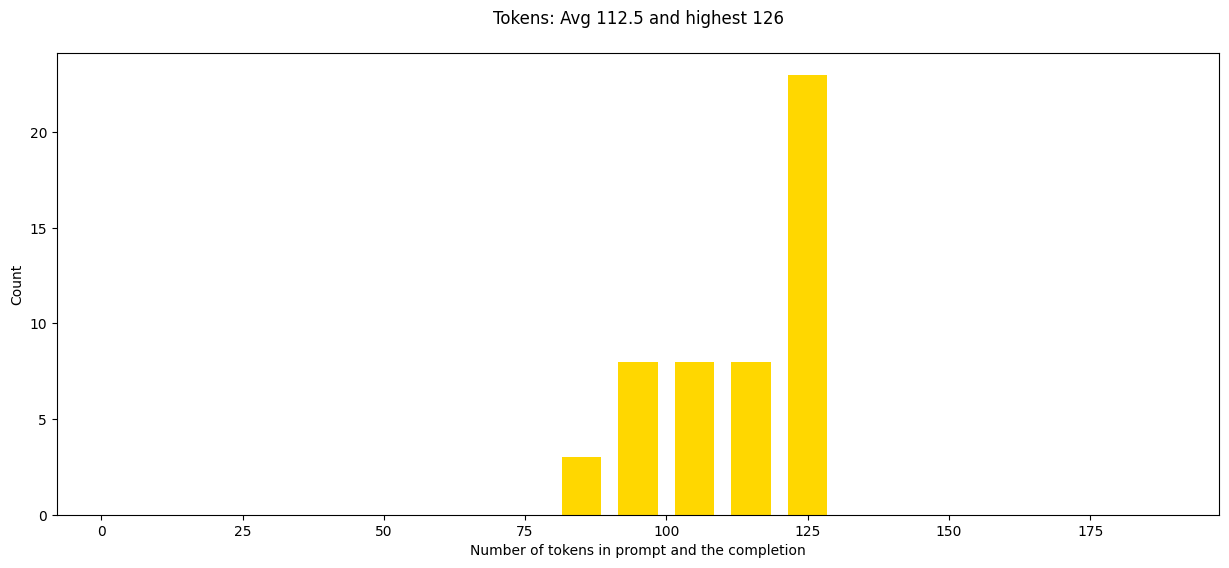

In [42]:
plt.figure(figsize=(15, 6))
plt.title(f"Tokens: Avg {sum(prompt_token_counts)/len(prompt_token_counts):,.1f} and highest {max(prompt_token_counts):,}\n")
plt.xlabel('Number of tokens in prompt and the completion')
plt.ylabel('Count')
plt.hist(prompt_token_counts, rwidth=0.7, color="gold", bins=range(0, 200, 10))
plt.show()

In [43]:
username = "SujithVarma2005"
dataset = f"{username}/items_prompts_lite" if LITE_MODE else f"{username}/items_prompts_full"

Item.push_prompts_to_hub(dataset, train, val, test)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

New Data Upload: |          |  0.00B /  0.00B            

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

## For open-source models fine-tuning, you usually create prompts.

The reason is that models like:

Llama 3.2

Gemma

Qwen

Mistral

are trained to predict the next token.